## SMBHB model 
This notebook provides the photometric model of Super Massive Black Hole Binaries for two components: 
- Stochastic Quasar Variability
- Doppler boosting
- Gravitational self-lensing

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from ipywidgets import *

# PlatoSim libraries
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# Paths to where data is stored
path = '/lhome/nicholas/software/workdir/smbhb'
fdir = '/lhome/nicholas/Nextcloud/paperSMBHB/figures'

---
## Physical model
---

### Example: Model Spikey 
Finally we define our constants and parameters of the SPIKEY SMBHB. We also define the time series here and convert necessary units from (seconds) to Modified Julian Date for a better comparison with the light curve produced by Hu et.al  

In [5]:
from platosim.varsource import SMBHB

In [9]:
# Parameters relating to Spikey (SI units)
z  = 0.962
P  = 1.144 * ut.year() * u.s                              
t0 = P * 3/4
M1 = 10**7.4 * u.M_sun                                                           
M2 = 10**6.7 * u.M_sun                                                                                                                      
e  = 0.524
i  = np.rad2deg(np.arccos(0.140)) * u.deg 
I  = 90 * u.deg - i
J  = np.pi/4 * u.deg  
w  = np.rad2deg(1.477) * u.deg
alpha = 2.09
F_lum = 0.89
wvl_c = 600 * u.nm

# Initialise model
dt   = 25
tdur = ut.year() * 3
time = np.arange(0, tdur, dt) * u.s                          
model = SMBHB(time, seed=12345)

### Grantional lensing

Model parameters:
Orbital period in rest frame  : 1.144 yr
Orbital period in obs. frame  : 2.244 yr
Mass total (M1 + M2)          : 30.1307 solMass x 1e6
Mass ratio (M2 / M1)          : 0.1995
Inclination of orbits         : 8.05 deg
Inclination of mini-disc      : 0.79 deg
Semi-major axis of binaries   : 340.36 AU
Schwarchild radius primary    : 106.63 solRad
Schwarchild radius secondary  : 21.28 solRad
Max Einstein radius primary   : 18.37 AU
Max Einstein radius secondary : 8.21 AU
2.2444800618845537 0.38226299694189597 2.4018292458637562
1.1439755667097622 0.75 4.71238898038469


<IPython.core.display.Javascript object>


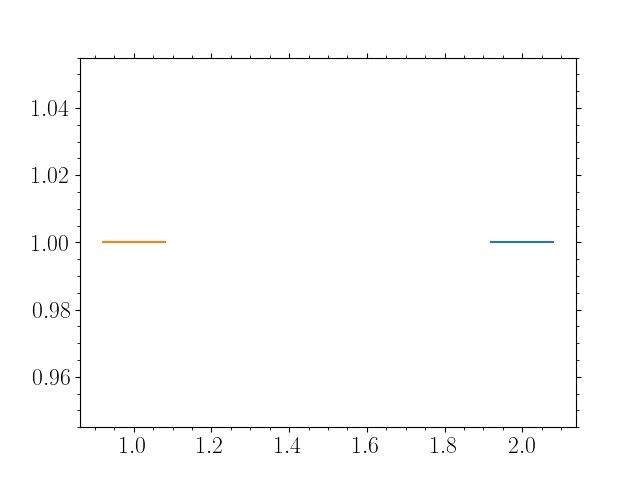

100%|██████████████████████████████████████████████████| 1000/1000 [00:00<00:00,


<IPython.core.display.Javascript object>


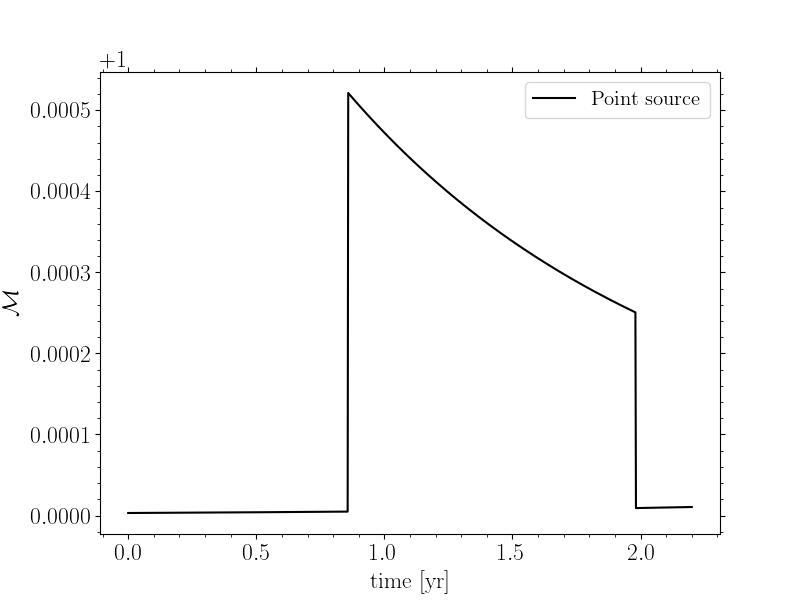

In [26]:
A = model.gravitational_lensing(z, t0, P, M1, M2, I, J, wvl=None)

In [7]:
# # Lensing events
# A1, A2, A = model.gravitational_lensing(t0, P, M1, M2, I, J, z)
# # flux_lens = (1 - flux_lum) * A1 + flux_lum * A2

# time = time.to('d')[::10000]
# fig = plt.figure(figsize = (8, 4))
# plt.plot(time, A1,        ':',  c='orange', label=r"$A_1$")
# plt.plot(time, A2,        '-.', c='orange', label=r"$A_2$")
# plt.plot(time, A,        '-', c='orange', label=r"$A$")
# # plt.plot(time.to('d'), flux_lens, '-',  c='orange', label=r"Lensing")
# # plt.plot(A1,        '-', c='orange', label=r"$A$")
# # plt.plot(A2,        '-', c='orange', label=r"$A$")

# # phi = np.linspace(0, 2*np.pi, len(time))
# # plt.plot(phi, A1,        ':',  c='orange', label=r"$A_1$")
# # plt.plot(phi, A2,        '-.', c='orange', label=r"$A_2$")
# # plt.plot(phi, flux_lens, '-',  c='orange', label=r"Lensing")

# plt.xlabel(r"Time [day]")
# plt.ylabel(r"Relative flux")
# # plt.xlim(0, time.to('d').value[-1])
# plt.legend()
# plt.tight_layout()

<IPython.core.display.Javascript object>


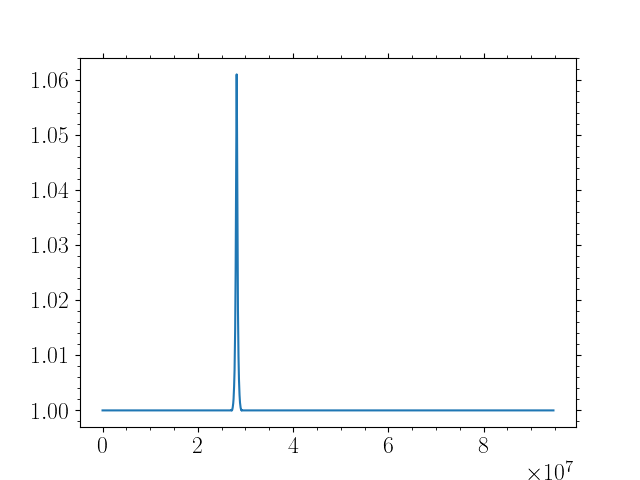

In [49]:
dx = pd.read_feather(f'{path}/lensing_model.ftr')

time0 = np.arange(0, t0.value, 25)
time1 = np.arange(t0.value, t0.value+25*dx.shape[0], 25)
time2 = np.arange(t0.value+25*dx.shape[0], tdur, 25)
time_lens = np.concatenate((time0, time1, time2))

flux0 = time0 * 0
flux1 = (dx.flux-dx.flux.min()) / 14
flux2 = time2 * 0
flux_lens = np.concatenate((flux0, flux1, flux2)) + 1

fig = plt.figure()
plt.plot(time_lens, flux_lens);

### Doppler boosting

<IPython.core.display.Javascript object>


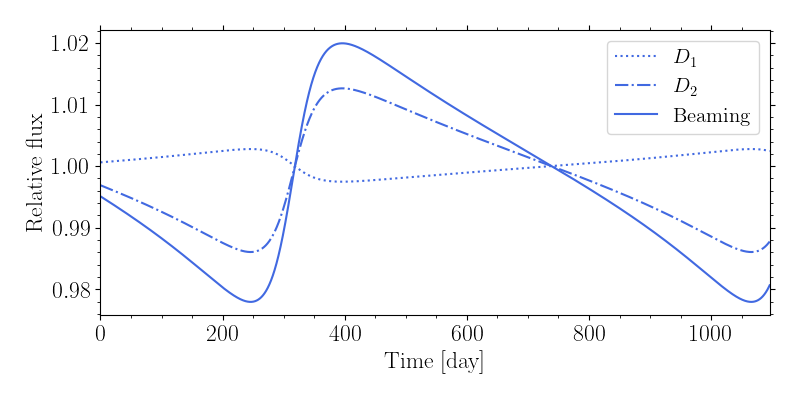

In [50]:
# Construct time array
D1, D2 = model.doppler_boosting(z, t0, P, M1, M2, i, e, w, alpha)
flux_beam = (1 - F_lum) * D1**(3 - alpha) + F_lum * D2**(3 - alpha)
flux_beam = (flux_beam - 1)*2 + 1

fig = plt.figure(figsize = (8, 4))
plt.plot(time.to('d'), D1,       ':',  c='royalblue', label=r"$D_1$")
plt.plot(time.to('d'), D2,       '-.', c='royalblue', label=r"$D_2$")
plt.plot(time.to('d'), flux_beam, '-', c='royalblue', label=r"Beaming")
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.legend()
plt.tight_layout()

### QSO variability (red noise)

<IPython.core.display.Javascript object>


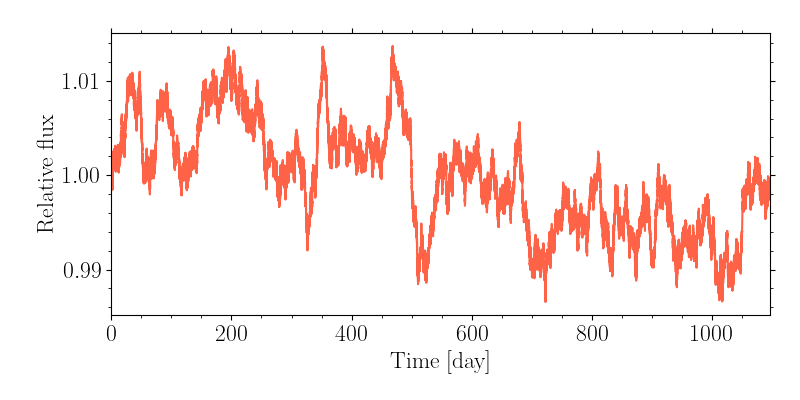

In [51]:
tau   = np.array([50]) * u.d
sigma = np.array([30]) # ppm

flux_red = model.quasar_variability(tau, sigma)

fig = plt.figure(figsize = (8, 4))
plt.plot(time.to('d'), flux_red, color='tomato')
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.tight_layout()

<IPython.core.display.Javascript object>


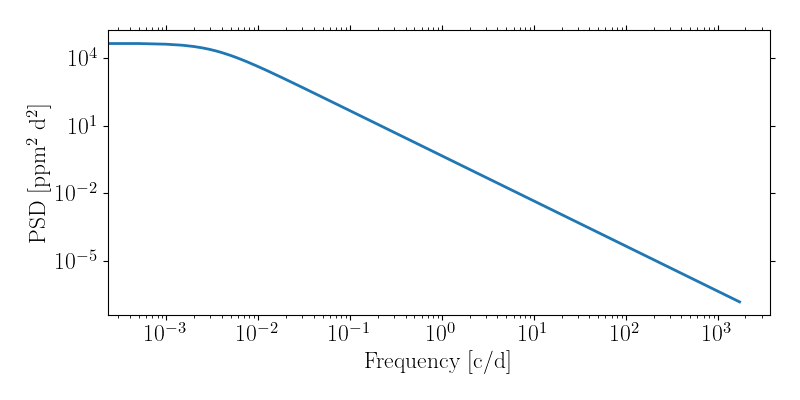

In [10]:
Nfreq = time.shape[0]
freq = np.arange(float(Nfreq)) / (Nfreq-1) * 0.5 / (dt * u.s).to('d').value
PSD = ns.modelRedNoisePSD(freq, tau.to('d').value, sigma)

fig = plt.figure(figsize = (8, 4))
for i in range(len(tau)):
    plt.loglog(freq, PSD, lw=2)
plt.xlabel(r"Frequency [c/d]")
plt.ylabel(r"PSD [ppm$^2$ d$^2$]")
plt.tight_layout()
plt.show()

### Combined model

<IPython.core.display.Javascript object>


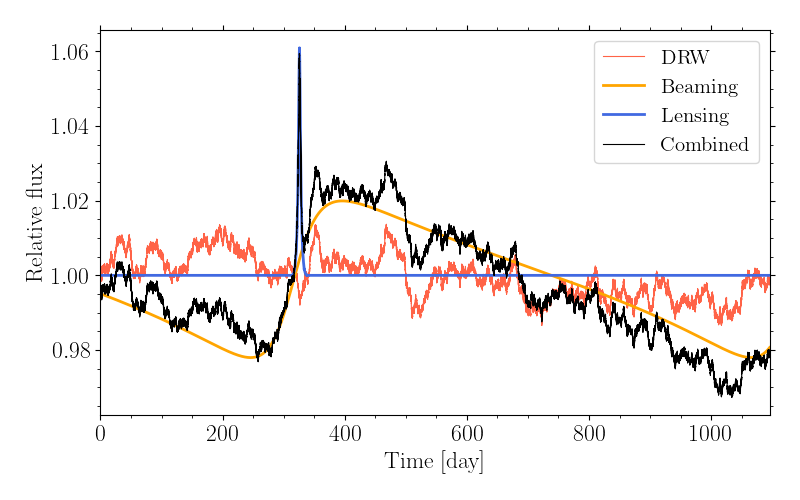

In [52]:
# Combined model (Beaming + QSO varibility)
flux = flux_beam * flux_red * flux_lens

# Plotting the combined (Doppler + Stochastic Quasar Variability) model
fig = plt.figure(figsize = (8, 5))
# plt.plot(time.to('d'), np.ones_like(time), '--', c='k')
plt.plot(time.to('d'), flux_red,  color='tomato',    label="DRW", lw=0.8)
plt.plot(time.to('d'), flux_beam, color='orange',    label="Beaming", lw=2)
plt.plot(time.to('d'), flux_lens, color='royalblue', label="Lensing", lw=2)
plt.plot(time.to('d'), flux,      color='k',         label="Combined", lw=0.8)
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.legend()
plt.tight_layout()

# Save figure
# fig.savefig(f'{fdir}/spikey_model.png', bbox_inches='tight', dpi=300)

In [105]:
# Save Spikey varsource file for PlatoSim
ofile = f'{path}/input/varsource_spikey.txt'
data = np.transpose([time, -2.5*np.log10(flux)])
# np.savetxt(ofile, data, fmt=['%.1f', '%.8f'])

<IPython.core.display.Javascript object>


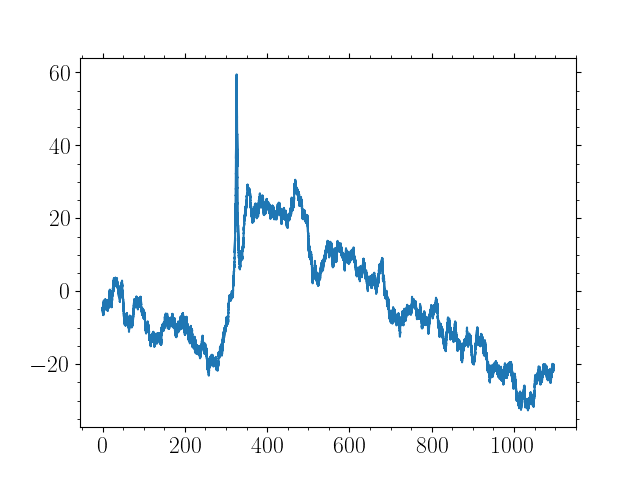

In [107]:
plt.figure()
# plt.plot(data[:,0], data[:,1])
plt.plot(time/86400, (flux-1)*1e3)

In [1]:
# # PLOT FOR THESIS COVER
# # Combined model (Beaming + QSO varibility)
# flux = flux_beam * flux_red * flux_lens
# # Plotting the combined model
# fig = plt.figure(figsize=(3.18,1.6))
# plt.plot(time.to('d'), flux, color='w', lw=0.8)
# plt.xlim(0, time.to('d').value[-1])
# plt.tight_layout()
# plt.xticks([])
# plt.yticks([])
# plt.axis('off')
# # Save figure
# tdir = '/lhome/nicholas/Nextcloud/thesis/image'
# fig.savefig(f'{tdir}/lightcurve_smbhb.png', bbox_inches='tight', dpi=300, transparent=True)